# Lab: Relationships Between Quantitative Features

Tropical cyclone intensity is described using several measurements. Two important features are maximum sustained wind speed and minimum central pressure. Their relationship is strong, but storms with the same wind speed can still have different pressures because storms differ in size, structure, environment, and stage of development.

Use the reproducible analysis workflow:

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can answer it?
3. **Operation:** What should the code select, calculate, or model?
4. **Check:** Does the result have sensible rows, values, units, and missingness?
5. **Evidence:** Which result directly answers the question?
6. **Conclusion and limitation:** What claim is supported, and what should we avoid concluding?


## Learning goals

By the end of this lab, you should be able to:

- create and interpret a scatterplot of two quantitative features;
- describe direction, form, strength, and unusual observations;
- calculate and interpret correlation, slope, and R-squared;
- interpret predicted values and residuals;
- evaluate whether latitude and longitude add predictive information; and
- identify limitations created by repeated observations of the same storm.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook's output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Background: What do wind and pressure measure?

A tropical cyclone is a rotating weather system organized around an area of relatively low atmospheric pressure.

**Maximum sustained wind** is the greatest estimated one-minute average wind speed occurring anywhere in the storm's circulation near the surface. In this file it is measured in **knots**. One knot is one nautical mile per hour, approximately 1.15 ordinary miles per hour. This is not the storm's forward travel speed, and it is not a brief wind gust.

**Minimum central pressure** is the lowest estimated atmospheric pressure near the storm's center. It is measured in **millibars (mb)**, a pressure unit numerically equivalent to hectopascals. Typical sea-level pressure outside a tropical cyclone is near 1,013 mb, although background pressure varies.

These two measurements describe different aspects of intensity:

- wind describes how rapidly air is moving near the surface; and
- central pressure describes how low the pressure is near the center.


## Why should they be related?

Air accelerates in response to differences in pressure. In a tropical cyclone, the contrast between the low pressure near the center and the higher pressure outside the storm helps support its rotating winds. In general, a larger pressure difference is associated with stronger winds. Therefore, as maximum sustained wind increases, minimum central pressure usually decreases.

The relationship is not one-to-one. Wind responds to the **pressure gradient**—how quickly pressure changes across distance—not only to the single pressure value at the center. Storm size, latitude, background pressure, structure, and whether a storm is strengthening or weakening can all affect the wind associated with a particular central pressure. A compact storm and a broad storm can consequently have different maximum winds even if their central pressures match.


## Why estimate one measurement from the other?

Wind and pressure are not always observed with equal completeness or confidence. Tropical cyclones may be far from surface weather stations, aircraft do not continuously sample every storm, and instruments can fail in destructive winds. Meteorologists combine aircraft, satellite, radar, buoy, ship, and land observations to reconstruct a storm's intensity.

A wind–pressure model can help:

- estimate a plausible value when one measurement is limited;
- check whether reported wind and pressure values are consistent with the usual relationship;
- reconstruct historical storm intensity from incomplete observations; and
- identify unusual storms that deserve closer investigation.

In this lab, **prediction** means the value on a statistical line given an observed wind speed. It does not mean forecasting where a storm will travel or how strong it will become. Operational intensity estimates use additional observations and specialized meteorological models—not this classroom regression alone.


## Dataset

The local dataset was prepared from NOAA's Atlantic HURDAT2 best-track database. It contains tropical and subtropical cyclone observations from 2020 through 2025.

Each row represents one best-track observation of one storm at a particular time. A storm appears in many rows as it develops, moves, and weakens.

| Feature | Description |
| --- | --- |
| `storm_id` | Basin, storm number, and year identifier |
| `storm_name` | Storm name |
| `observation_time` | Date and time of the best-track observation |
| `status` | Tropical or subtropical cyclone status code |
| `record_identifier` | Special-event code, such as landfall; usually blank |
| `latitude` | Latitude in signed decimal degrees |
| `longitude` | Longitude in signed decimal degrees |
| `maximum_sustained_wind_knots` | Maximum sustained wind speed in knots |
| `minimum_central_pressure_mb` | Minimum central pressure in millibars |

Status codes include `TD` for tropical depression, `TS` for tropical storm, `HU` for hurricane, `SD` for subtropical depression, and `SS` for subtropical storm. See `data/README.md` for provenance and preparation.


# Step 1: Question

> **How was maximum sustained wind speed related to minimum central pressure in Atlantic tropical and subtropical cyclone observations from 2020 through 2025, how useful was wind speed for predicting pressure, and did latitude or longitude add predictive information?**


**Which feature is the target and which feature is the predictor?**

Your answer: Predictor: maximum_sustained_wind_knots Target: minimum_central_pressure_mb



# Step 2: Data


## 1. Import the libraries

Import NumPy, Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Read the data

Read `data/atlantic_tropical_cyclone_observations_2020_2025.csv` into a DataFrame named `cyclones`. Use `parse_dates=["observation_time"]`.


In [2]:
cyclones = pd.read_csv(
    "data/atlantic_tropical_cyclone_observations_2020_2025.csv",
    parse_dates=["observation_time"]
)

## 3. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.


In [18]:
display(cyclones.head())
display(cyclones.tail())

cyclones.info()

display(cyclones.dtypes)
display(cyclones.isnull().sum())

,storm_id,storm_name,observation_time,status,record_identifier,latitude,longitude,maximum_sustained_wind_knots,minimum_central_pressure_mb
0,AL012020,Arthur,2020-05-16 18:00:00,TD,NaN,28.0,-78.7,30,1008
1,AL012020,Arthur,2020-05-17 00:00:00,TS,NaN,28.9,-78.0,35,1006
2,AL012020,Arthur,2020-05-17 06:00:00,TS,NaN,29.6,-77.6,35,1004
3,AL012020,Arthur,2020-05-17 12:00:00,TS,NaN,30.3,-77.5,35,1003
4,AL012020,Arthur,2020-05-17 18:00:00,TS,NaN,31.0,-77.3,40,1003


,storm_id,storm_name,observation_time,status,record_identifier,latitude,longitude,maximum_sustained_wind_knots,minimum_central_pressure_mb
2525,AL132025,Melissa,2025-10-30 06:00:00,HU,NaN,25.0,-73.8,85,968
2526,AL132025,Melissa,2025-10-30 12:00:00,HU,NaN,26.7,-72.7,90,965
2527,AL132025,Melissa,2025-10-30 18:00:00,HU,NaN,28.9,-70.9,85,967
2528,AL132025,Melissa,2025-10-31 00:00:00,HU,NaN,31.3,-68.7,80,970
2529,AL132025,Melissa,2025-10-31 06:00:00,HU,NaN,34.5,-65.5,75,972


<class 'pandas.DataFrame'>
RangeIndex: 2530 entries, 0 to 2529
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   storm_id                      2530 non-null   str           
 1   storm_name                    2530 non-null   str           
 2   observation_time              2530 non-null   datetime64[us]
 3   status                        2530 non-null   str           
 4   record_identifier             122 non-null    str           
 5   latitude                      2530 non-null   float64       
 6   longitude                     2530 non-null   float64       
 7   maximum_sustained_wind_knots  2530 non-null   int64         
 8   minimum_central_pressure_mb   2530 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 216.5 KB


storm_id                                   str
storm_name                                 str
observation_time                datetime64[us]
status                                     str
record_identifier                          str
latitude                               float64
longitude                              float64
maximum_sustained_wind_knots             int64
minimum_central_pressure_mb              int64
dtype: object

storm_id                           0
storm_name                         0
observation_time                   0
status                             0
record_identifier               2408
latitude                           0
longitude                          0
maximum_sustained_wind_knots       0
minimum_central_pressure_mb        0
dtype: int64

Complete the table using the data dictionary, `.info()`, and `.isnull().sum()`.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `storm_id` | Categorical / identifier | str | 0 |
| `storm_name` | Categorical | str | 0 |
| `observation_time` | Date/time | datetime64[us] | 0 |
| `status` | Categorical | str | 0 |
| `record_identifier` | Categorical | str | 2408 |
| `latitude` | Quantitative | float64 | 0 |
| `longitude` | Quantitative | float64 | 0 |
| `maximum_sustained_wind_knots` | Quantitative | int64 | 0 |
| `minimum_central_pressure_mb` | Quantitative | int64 | 0 |


**What does one row represent?**

Your answer: One row represents one best track observation of a tropical or subtropical cyclone at a specific time.



**Why are blank `record_identifier` values not a reason to remove observations from this analysis?**

Your answer: Blank record_identifier values are not a reason to remove observations because this feature is only used to mark special events, such as landfall, and it is usually blank. The analysis focuses on wind speed, pressure, latitude, and longitude, so a blank value in record_identifier does not make the observation unusable.


# Step 3: Operation


## 4. Select the model features

Create `model_features` containing `maximum_sustained_wind_knots`, `minimum_central_pressure_mb`, `latitude`, and `longitude` in that order.


In [4]:
model_features = [
    "maximum_sustained_wind_knots",
    "minimum_central_pressure_mb",
    "latitude",
    "longitude"
]

## 5. Create the analysis DataFrame

Models can only be compared fairly when they are built from the same observations. Create `analysis` by dropping records missing any feature that might be included in the models, and then call `.copy()`.


In [5]:
analysis = cyclones.dropna(subset=model_features).copy()

**Why would replacing a missing wind or pressure value with zero be inappropriate?**

Your answer: Replacing a missing wind or pressure value with zero would be inappropriate because zero would be treated as a real measurement. This could create unrealistic values and distort the relationship between wind speed and central pressure.



In the next class, you will learn another strategy for handling some kinds of missing data called **interpolation**. Interpolation estimates a missing value using nearby observations, but it is not appropriate automatically for every feature or dataset.


# Step 4: Check


## 6. Check the analysis data

Display:

- missing-value counts for `model_features`; and
- `.describe()` for the four model features, rounded to one decimal place.


In [6]:
analysis[model_features].isnull().sum()
analysis[model_features].describe().round(1)

,maximum_sustained_wind_knots,minimum_central_pressure_mb,latitude,longitude
count,2530.0,2530.0,2530.0,2530.0
mean,56.2,989.9,24.1,-63.7
std,26.6,20.7,8.6,20.0
min,20.0,892.0,7.8,-126.6
25%,35.0,981.0,17.1,-80.7
50%,45.0,998.0,22.4,-63.6
75%,70.0,1005.0,30.8,-47.8
max,165.0,1015.0,48.8,-7.6


**How many observations remain? Report the ranges and units of wind speed and pressure.**

Your answer: There are 2,530 observations remaining. Maximum sustained wind speed ranges from 20 to 165 knots, and minimum central pressure ranges from 892 to 1,015 millibars.


# Step 5: Evidence


## 7. Create a scatterplot

Use `sns.scatterplot()` with wind speed on the x-axis and pressure on the y-axis. Set `alpha=0.35` and use the named color `"steelblue"`. Add a question-focused title and axis labels that include units.


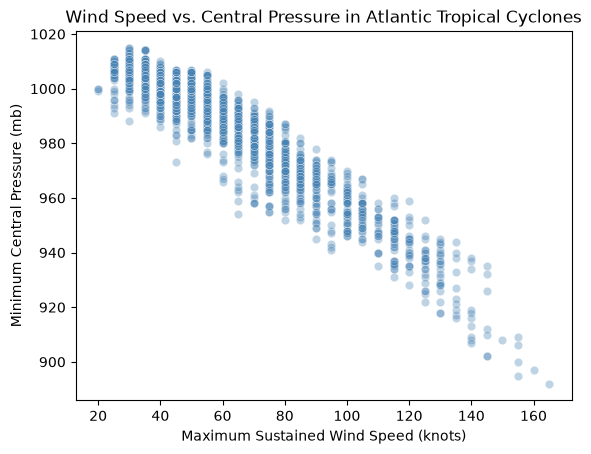

In [7]:
sns.scatterplot(
    data=analysis,
    x="maximum_sustained_wind_knots",
    y="minimum_central_pressure_mb",
    alpha=0.35,
    color="steelblue"
)

plt.title("Wind Speed vs. Central Pressure in Atlantic Tropical Cyclones")
plt.xlabel("Maximum Sustained Wind Speed (knots)")
plt.ylabel("Minimum Central Pressure (mb)")
plt.show()

**Describe the relationship's direction, form, strength, and unusual observations.**

Your answer: There is a strong negative relationship between maximum sustained wind speed and minimum central pressure. As wind speed increases, central pressure generally decreases. The pattern is fairly smooth and approximately linear, although there is some curvature at higher wind speeds. The points are fairly tightly grouped around the overall trend, so the relationship appears strong. There are a few observations that fall farther from the main pattern, but there are no obvious extreme outliers.

## 8. Calculate the correlation

Create `correlation_matrix` from wind speed and pressure. Select the appropriate cell, save it as `correlation`, and display the correlation rounded to three decimal places.


In [8]:
correlation_matrix = analysis[
    ["maximum_sustained_wind_knots", "minimum_central_pressure_mb"]
].corr()

correlation = correlation_matrix.loc[
    "maximum_sustained_wind_knots",
    "minimum_central_pressure_mb"
]

round(correlation, 3)

np.float64(-0.955)

**Report and interpret the correlation. Why is the scatterplot still necessary?**

Your answer: The correlation between maximum sustained wind speed and minimum central pressure is -0.955. This indicates a very strong negative linear relationship, meaning that as wind speed increases, central pressure tends to decrease. The scatterplot is still necessary because correlation only summarizes the strength and direction of a linear relationship. The scatterplot can also show curvature, clusters, spread, and unusual observations that the correlation value alone does not reveal.


## 9. Calculate the fitted line

Create `x` from wind speed and `y` from pressure. Calculate:

- `slope` as the covariance of `x` and `y` divided by the variance of `x`;
- `intercept` from the two feature means and the slope; and
- `slope_per_10_knots` as ten times the slope.

The calculation is provided so you can focus on interpreting the result.


In [9]:
x = analysis["maximum_sustained_wind_knots"]
y = analysis["minimum_central_pressure_mb"]

slope = x.cov(y) / x.var()
intercept = y.mean() - slope * x.mean()
slope_per_10_knots = slope * 10

print("Slope:", round(slope, 3))
print("Intercept:", round(intercept, 3))
print("Change per 10 knots:", round(slope_per_10_knots, 3))


Slope: -0.743
Intercept: 1031.604
Change per 10 knots: -7.43


**Interpret `slope_per_10_knots` in context. Does the slope establish a causal mechanism?**

Your answer: For every 10 knot increase in maximum sustained wind speed, the model predicts that minimum central pressure decreases by about 7.43 millibars on average. The slope does not establish a causal mechanism, it only describes the statistical relationship between wind speed and central pressure in these observations.


## 10. Display the fitted line

Use `sns.regplot()` with the same x and y features. Use `color="teal"` and `scatter_kws={"alpha": 0.25}`. Add descriptive labels.


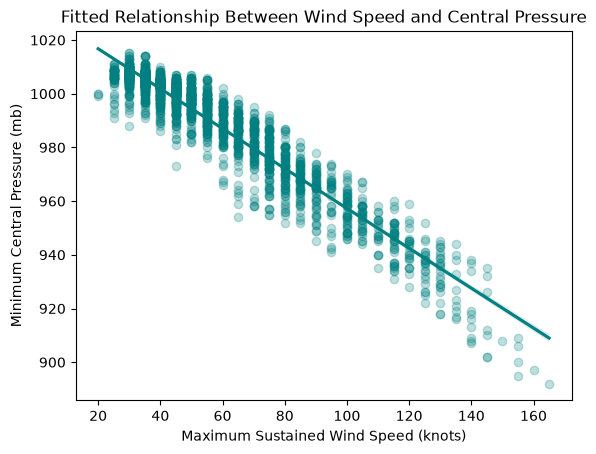

In [10]:
sns.regplot(
    data=analysis,
    x="maximum_sustained_wind_knots",
    y="minimum_central_pressure_mb",
    color="teal",
    scatter_kws={"alpha": 0.25}
)

plt.title("Fitted Relationship Between Wind Speed and Central Pressure")
plt.xlabel("Maximum Sustained Wind Speed (knots)")
plt.ylabel("Minimum Central Pressure (mb)")
plt.show()

## 11. Calculate R-squared

Create `r_squared` by squaring `correlation`, then display it rounded to three decimal places.


In [11]:
r_squared = correlation ** 2

round(r_squared, 3)

np.float64(0.912)

**Interpret R-squared in the context of this analysis.**

Your answer: The R squared value is 0.912, which means about 91.2% of the variation in minimum central pressure is explained by its linear relationship with maximum sustained wind speed in these observations.


## 12. Calculate predictions and residuals

Create two new columns:

- `analysis["predicted_pressure_mb"]`, calculated from the intercept, slope, and wind speed; and
- `analysis["residual_pressure_mb"]`, calculated as observed pressure minus predicted pressure.

Display the first five rows of the storm name, wind, observed pressure, predicted pressure, and residual.


In [12]:
analysis["predicted_pressure_mb"] = (
    intercept + slope * analysis["maximum_sustained_wind_knots"]
)

analysis["residual_pressure_mb"] = (
    analysis["minimum_central_pressure_mb"]
    - analysis["predicted_pressure_mb"]
)

analysis[
    [
        "storm_name",
        "maximum_sustained_wind_knots",
        "minimum_central_pressure_mb",
        "predicted_pressure_mb",
        "residual_pressure_mb"
    ]
].head()

,storm_name,maximum_sustained_wind_knots,minimum_central_pressure_mb,predicted_pressure_mb,residual_pressure_mb
0,Arthur,30,1008,1009.313742,-1.313742
1,Arthur,35,1006,1005.598751,0.401249
2,Arthur,35,1004,1005.598751,-1.598751
3,Arthur,35,1003,1005.598751,-2.598751
4,Arthur,40,1003,1001.883760,1.116240


**What do positive and negative pressure residuals mean?**

Your answer: A positive pressure residual means the observed central pressure was higher than the model predicted. A negative pressure residual means the observed central pressure was lower than the model predicted.



# Do geographic covariates add information?

Wind and pressure may also depend on where a storm is located. The following provided code converts latitude and longitude into **tertiles: three groups containing approximately equal numbers of observations**. These are descriptive categories rather than physical storm boundaries.


In [13]:
analysis["latitude_group"] = pd.qcut(
    analysis["latitude"],
    q=3,
    labels=["Lower latitude", "Middle latitude", "Higher latitude"]
)

analysis["longitude_group"] = pd.qcut(
    analysis["longitude"],
    q=3,
    labels=["Western", "Central", "Eastern"]
)


## 13. Compare the relationships visually

Create two `sns.lmplot()` figures. In both figures, use wind as `x`, pressure as `y`, `scatter_kws={"alpha": 0.25}`, and `legend=False`. The `hue` argument assigns colors and separate fitted lines to the three groups.

For the first figure, use `hue="latitude_group"` and `palette="viridis"`. Add a descriptive title and axis labels with units, then add a legend titled `"Latitude group"`.

For the second figure, use `hue="longitude_group"` and `palette="magma"`. Add a descriptive title and axis labels with units, then add a legend titled `"Longitude group"`.


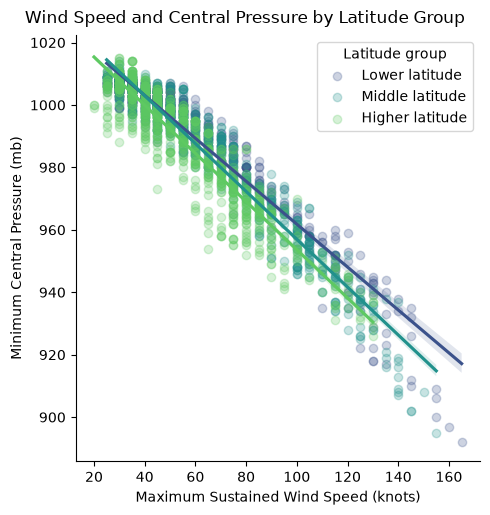

In [14]:
g = sns.lmplot(
    data=analysis,
    x="maximum_sustained_wind_knots",
    y="minimum_central_pressure_mb",
    hue="latitude_group",
    palette="viridis",
    scatter_kws={"alpha": 0.25},
    legend=False
)

g.set_axis_labels(
    "Maximum Sustained Wind Speed (knots)",
    "Minimum Central Pressure (mb)"
)

g.fig.suptitle(
    "Wind Speed and Central Pressure by Latitude Group",
    y=1.02
)

plt.legend(title="Latitude group")
plt.show()

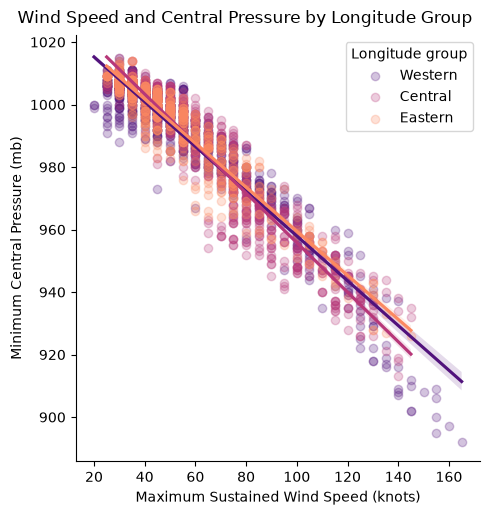

In [15]:
g = sns.lmplot(
    data=analysis,
    x="maximum_sustained_wind_knots",
    y="minimum_central_pressure_mb",
    hue="longitude_group",
    palette="magma",
    scatter_kws={"alpha": 0.25},
    legend=False
)

g.set_axis_labels(
    "Maximum Sustained Wind Speed (knots)",
    "Minimum Central Pressure (mb)"
)

g.fig.suptitle(
    "Wind Speed and Central Pressure by Longitude Group",
    y=1.02
)

plt.legend(title="Longitude group")
plt.show()

**Which figure shows greater separation among its fitted lines? What does that suggest about which geographic feature may add more information?**

Your answer: The latitude group figure shows greater separation among its fitted lines. This suggests that latitude may add more predictive information about minimum central pressure beyond wind speed than longitude does.


## 14. Compare R-squared values

You are not expected to reproduce the multiple-predictor calculation below. Run the provided code and focus on interpreting the R-squared values. `pd.get_dummies()` converts the categories into 0/1 indicator columns, and NumPy fits each least-squares model.


In [16]:
def calculate_r_squared(data, categorical_features):
    predictors = pd.get_dummies(
        data[
            ["maximum_sustained_wind_knots", *categorical_features]
        ],
        columns=categorical_features,
        drop_first=True,
        dtype=float
    )
    predictors.insert(0, "intercept", 1.0)

    x = predictors.to_numpy()
    y = data["minimum_central_pressure_mb"].to_numpy()
    coefficients = np.linalg.lstsq(x, y, rcond=None)[0]
    predicted = x @ coefficients

    residual_sum_squares = ((y - predicted) ** 2).sum()
    total_sum_squares = ((y - y.mean()) ** 2).sum()
    return 1 - residual_sum_squares / total_sum_squares


In [17]:
model_comparison = pd.Series(
    {
        "Wind only": calculate_r_squared(analysis, []),
        "Wind + latitude group": calculate_r_squared(
            analysis, ["latitude_group"]
        ),
        "Wind + longitude group": calculate_r_squared(
            analysis, ["longitude_group"]
        ),
        "Wind + both groups": calculate_r_squared(
            analysis, ["latitude_group", "longitude_group"]
        )
    },
    name="r_squared"
)

model_comparison.round(3)


Wind only                 0.912
Wind + latitude group     0.920
Wind + longitude group    0.913
Wind + both groups        0.920
Name: r_squared, dtype: float64

**Which geographic covariate adds more information beyond wind? Does either covariate produce a large improvement in R-squared?**

Your answer: Latitude adds more predictive information beyond wind speed than longitude. Adding latitude increases R squared from 0.912 to 0.920, while adding longitude only increases it to 0.913. Neither geographic covariate produces a large improvement in R squared, and including both groups does not improve the model beyond the 0.920 achieved with latitude alone.


# Step 6: Conclusion and limitation


**Write a concise conclusion that uses the correlation, slope, and R-squared values to answer the research question.**

Your answer: Maximum sustained wind speed and minimum central pressure had a very strong negative relationship, with a correlation of -0.955. The fitted line showed that for every 10 knot increase in wind speed, predicted central pressure decreased by about 7.43 millibars. The R squared value of 0.912 means wind speed explained about 91.2% of the variation in central pressure. Latitude added a small amount of predictive information, while longitude added very little. These results describe the observed relationship in the 2020-2025 best track data and should not be interpreted as a causal model or a forecast of future storm intensity. Because the same storm can appear in multiple observations, the rows are not completely independent.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer: I used an AI tool to help explain the analysis steps and interpret the results. One suggestion I checked was the interpretation of the correlation and R squared values. I compared the explanation with my notebook output and accepted it because the values matched my results and the interpretation was consistent with the scatterplot and model output.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Include units in interpretations and figure labels.
- Describe direction, form, strength, and unusual observations.
- Interpret slope, R-squared, and residuals in context.
- Interpret predictions and residuals in context.
- Create and compare the latitude- and longitude-group `lmplot` figures.
- Distinguish best-track description from forecasting.
- Complete the AI-use reflection.
